In [157]:
import numpy as np
import matplotlib.pyplot as plt

In [158]:
def init_params_es(n):
    # Population size (lambda)
    pop_size = 4 + int(3 * np.log(n))

    # Number of parents (mu)
    mu = pop_size // 2

    # w_i: weights for mean update
    weights = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1))
    weights /= np.sum(weights) # Normalize to sum 1

    mu_w = 1 / np.sum(weights ** 2)
    c_1 = 2 / n ** 2
    c_mu = mu_w / n ** 2

    # Learning rates
    c_sigma = (mu_w + 2) / (n + mu_w + 5)
    c_c = (4 + mu_w / n) / (n + 4 + 2 * mu_w / n)

    return {
        "n": n,
        "pop_size": pop_size, "mu": mu, "weights": weights, "mu_w": mu_w,
        "c_1": c_1, "c_mu": c_mu, "c_sigma": c_sigma, "c_c": c_c,
        "m": np.random.uniform(-5, 5, n),       # Init core
        "sigma": 0.5,                           # Init step size
        "C": np.eye(n),                         # Covariance matrix
        "p_c": np.zeros(n),                     # Evol path for C
        "p_sigma": np.zeros(n)                  # Evol path for sigma
    }

In [159]:
def target_function(x):
    return sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1.0 - x[:-1])**2.0)

def evolutionary_strategy(
        n_vars,
        max_gens = 300,
):
    # Init params
    params = init_params_es(n=n_vars)

    fitness_history = []

    for gen in range(max_gens):

        # Step 2
        vals, vecs = np.linalg.eigh(params["C"])
        D = np.diag(np.sqrt(np.maximum(0, vals)))
        BD = np.dot(vecs, D)

        z = np.random.randn(params["pop_size"], n_vars)
        y = np.dot(z, BD.T)
        x = params["m"] + params["sigma"] * y

        # Step 3: Calculate fitness
        fitness = np.array([target_function(ind) for ind in x])

        # Step 4: Selection
        indices = np.argsort(fitness)
        y_sel = y[indices[:params["mu"]]]
        x_sel = x[indices[:params["mu"]]]

        # Step 5: Update core m
        y_w = np.sum(y_sel * params["weights"][:, np.newaxis], axis=0)
        # params["m"] = params["m"] + params["sigma"] * y_w
        params["m"] = np.sum(x_sel * params["weights"][:, np.newaxis], axis=0)

        # Step 6: Update p_sigma, hướng của m
        C_inv_half = np.linalg.multi_dot([vecs, np.diag(1.0 / np.sqrt(np.maximum(1e-10, vals))), vecs.T])
        params["p_sigma"] = (1 - params["c_sigma"]) * params["p_sigma"] + \
            np.sqrt(1 - (1 - params["c_sigma"]) ** 2 ) * np.sqrt(params["mu_w"]) * np.dot(C_inv_half, y_w)

        # Step 7: Update sigma, tốc độ m di chuyển
        p_sigma_norm = np.linalg.norm(params["p_sigma"])
        params["sigma"] = params["sigma"] * np.exp(params["c_sigma"] * (p_sigma_norm  / np.sqrt(params["n"]) - 1))

        # Step 8: Update p_c, nhớ hướng đi
        params["p_c"] = (1 - params["c_c"]) * params["p_c"] + \
            np.sqrt(1 - (1 - params["c_c"]) ** 2 ) * np.sqrt(params["mu_w"]) * y_w

        # Step 9: Update C, phạm vi vùng tìm kiếm
        rank_1 = params["c_1"] * np.outer(params["p_c"], params["p_c"])
        rank_mu = np.zeros((n_vars, n_vars))
        for i in range(params["mu"]):
            rank_mu += params["weights"][i] * np.outer(y_sel[i], y_sel[i])

        params["C"] = (1 - params["c_1"] - params["c_mu"]) * params["C"] + rank_1 + params["c_mu"]  *rank_mu

        fitness_history.append(np.min(fitness))

        if gen % 30 == 0 or gen == max_gens - 1:
            best_f = np.min(fitness)
            print(f"Gen {gen} - Best fitness: {best_f:.4f} | Sigma: {params['sigma']:.4f} | Mean: {params['m']}")

    return params['m'], np.min(fitness), fitness_history

Gen 0 - Best fitness: 89595.2194 | Sigma: 0.4536 | Mean: [-0.3560672  -3.62914824  3.2192835  -1.91244606 -1.74208463 -3.80632687
 -4.32575385  3.15738619]
Gen 30 - Best fitness: 275.6724 | Sigma: 0.2945 | Mean: [ 0.1109982  -0.02571306  0.45749862  0.46164973  0.2621928   0.0504516
 -1.26117562  2.41980898]
Gen 60 - Best fitness: 22.9288 | Sigma: 0.2811 | Mean: [ 0.59331255  0.53784707  0.23157207  0.03554001  0.05183783 -0.01154407
 -0.00480509 -0.19389971]
Gen 90 - Best fitness: 5.2568 | Sigma: 0.0294 | Mean: [0.60849272 0.36804026 0.14464285 0.04212487 0.01622835 0.00598635
 0.00915661 0.00635998]
Gen 120 - Best fitness: 4.3345 | Sigma: 0.0524 | Mean: [ 0.79510216  0.6358711   0.39570811  0.15736334  0.02547149 -0.01743534
  0.01386102 -0.00220284]
Gen 150 - Best fitness: 3.4165 | Sigma: 0.0577 | Mean: [0.87918756 0.7733608  0.59534616 0.34032813 0.11700428 0.02857358
 0.02583286 0.00269643]
Gen 180 - Best fitness: 2.1766 | Sigma: 0.1490 | Mean: [0.94508546 0.89598942 0.80873879 0.

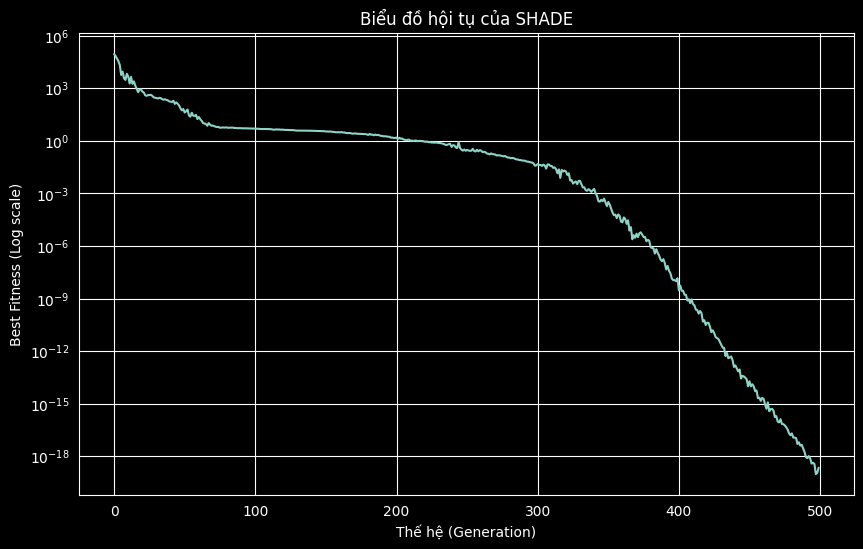

In [160]:
best_m, best_f, fitness_history = evolutionary_strategy(n_vars=8, max_gens=500)
print(f"Best mean: {best_m} | Best fitness: {best_f}")

plt.figure(figsize=(10, 6))
plt.plot(fitness_history)
# plt.plot(np.array(fitness_history) + 1e-20)
plt.yscale('log')
plt.title('Biểu đồ hội tụ của SHADE')
plt.xlabel('Thế hệ (Generation)')
plt.ylabel('Best Fitness (Log scale)')
plt.grid(True, which="both", ls="-")
plt.show()